# Ten Years of Williamsburg, One Community Board at a Time

Every month since (at least) 2016, Brooklyn Community Board 1 — Williamsburg and
Greenpoint — has met, argued, voted, and published minutes as PDFs: image scans,
dirty OCR, handwritten roll-call sheets, 300-page attachment dumps. This notebook
queries a structured dataset extracted from all 110 of those meetings with a
tiered LLM pipeline (total extraction + OCR cost: ~$17).

Every record carries a verbatim `source_snippet` from the minutes, and vote-tally
accuracy is gated by an eval harness. Pipeline, eval design, and caveats:
see the repo's `PLAN.md` and `README.md`.

Data: five parquet files. No database server, no API — just DuckDB.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

con = duckdb.connect()
for t in ("meetings", "licenses", "votes", "speakers", "incidents", "cannabis"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '../data/db/{t}.parquet'")

def q(sql):
    return con.execute(sql).df()

q("SELECT count(*) AS meetings, min(date) AS first, max(date) AS last FROM meetings")

,meetings,first,last
0,110,2016-01-12,2026-06-09


## The corpus: four eras of document quality

The dataset covers every era of civic record-keeping: pure image scans (2016–18,
transcribed with vision OCR), scans with a dirty embedded text layer (2019–21),
and native digital text (2022+). `text_source` records which path each meeting
took — provenance matters when you're about to make quantitative claims.

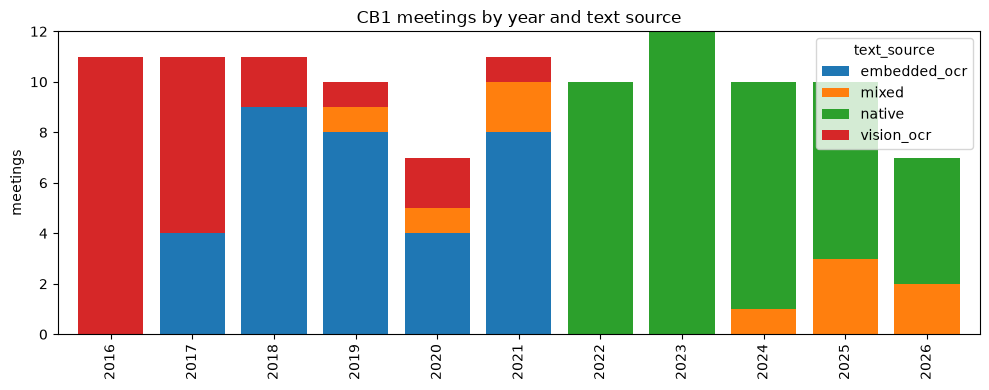

In [2]:
df = q("""
    SELECT year(date) AS yr, text_source, count(*) AS n
    FROM meetings GROUP BY 1, 2 ORDER BY 1
""").pivot(index="yr", columns="text_source", values="n").fillna(0)

ax = df.plot.bar(stacked=True, figsize=(10, 4), width=0.8)
ax.set_title("CB1 meetings by year and text source")
ax.set_xlabel("")
ax.set_ylabel("meetings")
plt.tight_layout()

## 1. The COVID cliff

Liquor-license items are the board's bread and butter — every new bar,
renewal, and sidewalk-cafe alteration in the district crosses its agenda.
Which makes the docket a proxy for the nightlife economy. Watch 2020.

,yr,applications,new_applications
0,2016,345,112
1,2017,301,99
2,2018,438,141
3,2019,712,218
4,2020,128,34
5,2021,482,169
6,2022,598,243
7,2023,512,169
8,2024,631,210
9,2025,545,206


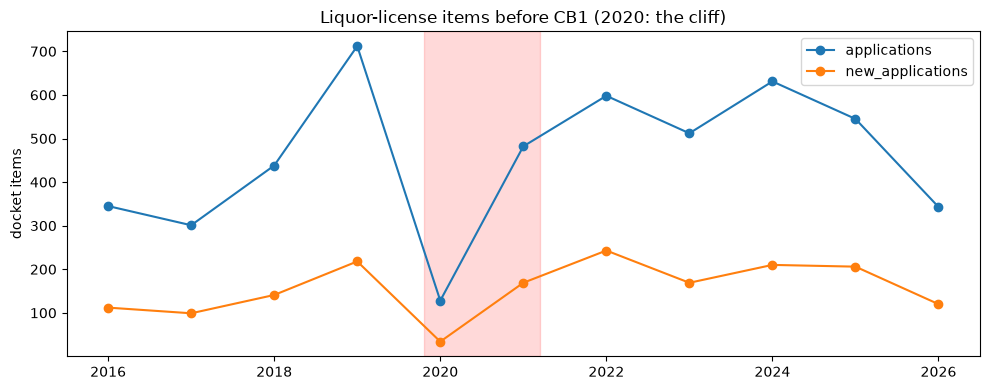

In [3]:
df = q("""
    SELECT year(m.date) AS yr,
           count(*) AS applications,
           count(*) FILTER (WHERE l.application_type = 'new') AS new_applications
    FROM licenses l JOIN meetings m USING (meeting_id)
    GROUP BY 1 ORDER BY 1
""")
ax = df.set_index("yr")[["applications", "new_applications"]].plot(
    kind="line", marker="o", figsize=(10, 4))
ax.set_title("Liquor-license items before CB1 (2020: the cliff)")
ax.set_ylabel("docket items")
ax.set_xlabel("")
ax.axvspan(2019.8, 2021.2, alpha=0.15, color="red")
plt.tight_layout()
df

2019's docket ran ~700 items; 2020 collapsed to ~130 — an 82% drop — and the
recovery took two years. (Caveat for the write-up: 2019 is a dirty-OCR year;
the level is pending golden-set verification, but the cliff's shape survives
any plausible error bar.)

## 2. You can measure board conflict

Most community-board votes are unanimous. The interesting signal is the
*contested-vote rate*: what share of tallied motions drew at least one "no."

,yr,tallied,contested,contested_pct
0,2016,119,23,19.327731
1,2017,79,14,17.721519
2,2018,100,35,35.000000
3,2019,111,22,19.819820
4,2020,55,9,16.363636
5,2021,119,18,15.126050
6,2022,99,41,41.414141
7,2023,93,13,13.978495
8,2024,173,14,8.092486
9,2025,140,28,20.000000


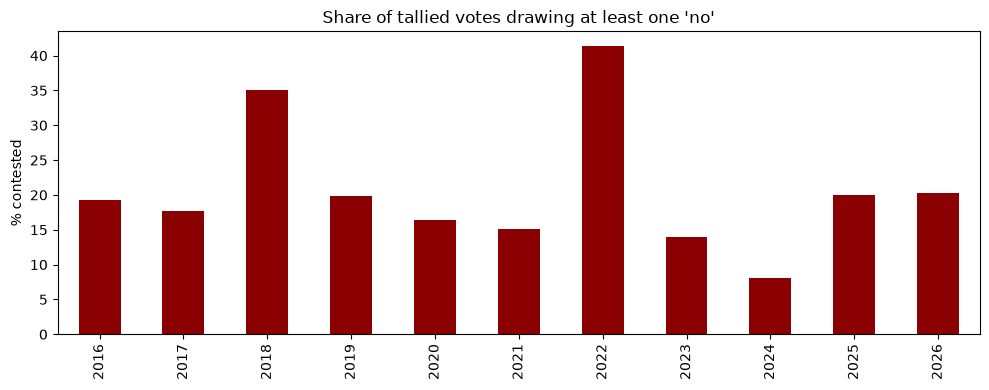

In [4]:
df = q("""
    SELECT year(m.date) AS yr,
           count(*) FILTER (WHERE v.yes + v.no > 0) AS tallied,
           count(*) FILTER (WHERE v.no > 0) AS contested
    FROM votes v JOIN meetings m USING (meeting_id)
    GROUP BY 1 ORDER BY 1
""")
df["contested_pct"] = 100 * df.contested / df.tallied
ax = df.set_index("yr")["contested_pct"].plot(
    kind="bar", figsize=(10, 4), color="#8B0000")
ax.set_title("Share of tallied votes drawing at least one 'no'")
ax.set_ylabel("% contested")
ax.set_xlabel("")
plt.tight_layout()
df

Two spikes: 2018 (34%) and 2022 (41%). The 2022 number has a face: an October
2022 vote of no confidence in the board's own leadership. It failed 9–16 —
and the following year, the contested rate fell back to 14%, then to 8% in
2024, the calmest year in the dataset.

In [5]:
q("""
    SELECT m.date, v.motion_text, v.yes, v.no, v.abstain, v.outcome, v.source_snippet
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE v.motion_text ILIKE '%confidence%'
    ORDER BY m.date
""")

,date,motion_text,yes,no,abstain,outcome,source_snippet
0,2022-10-11,Vote of no confidence in the Chair and Vice Ch...,9,16,6,failed,He moved for a vote of no confidence. The moti...


## 3. Cannabis walks in the door

Seven years of silence, then New York legalizes retail cannabis and a new
category of civic workload appears, fully formed, in 2023.

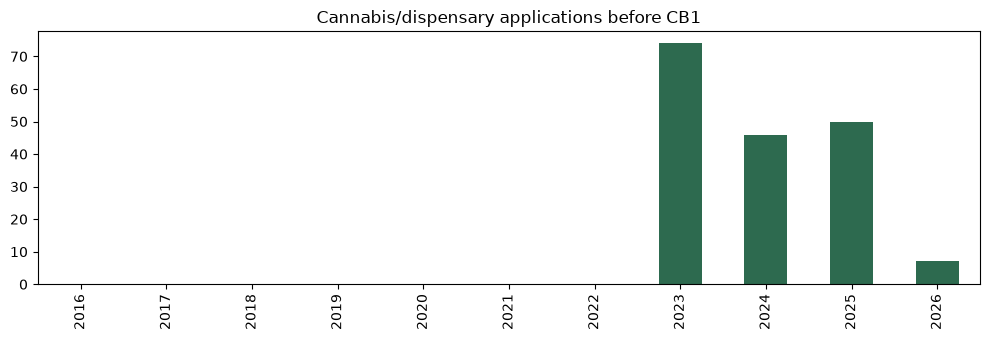

In [6]:
df = q("""
    SELECT year(m.date) AS yr, count(*) AS applications
    FROM cannabis c JOIN meetings m USING (meeting_id)
    GROUP BY 1 ORDER BY 1
""")
full = pd.DataFrame({"yr": range(2016, 2027)}).merge(df, on="yr", how="left").fillna(0)
ax = full.set_index("yr")["applications"].plot(kind="bar", figsize=(10, 3.5), color="#2d6a4f")
ax.set_title("Cannabis/dispensary applications before CB1")
ax.set_xlabel("")
plt.tight_layout()

## 4. The community says no; the board says yes

Public-session speakers on liquor and nightlife topics oppose applications
3.4-to-1. Yet among license items with a recorded disposition, ~88% are
approved. The mechanics explain the gap: renewals are batch-approved in a
single committee-report vote, while opposition concentrates on a handful of
contested newcomers — which *do* get denied at multiples of the base rate.

And then there's 2025: the first year testimony ran pro-nightlife.

,yr,against,pro
0,2016,26,7
1,2017,22,5
2,2018,8,10
3,2019,13,0
4,2020,3,0
5,2021,12,1
6,2022,27,4
7,2023,25,3
8,2024,16,10
9,2025,7,15


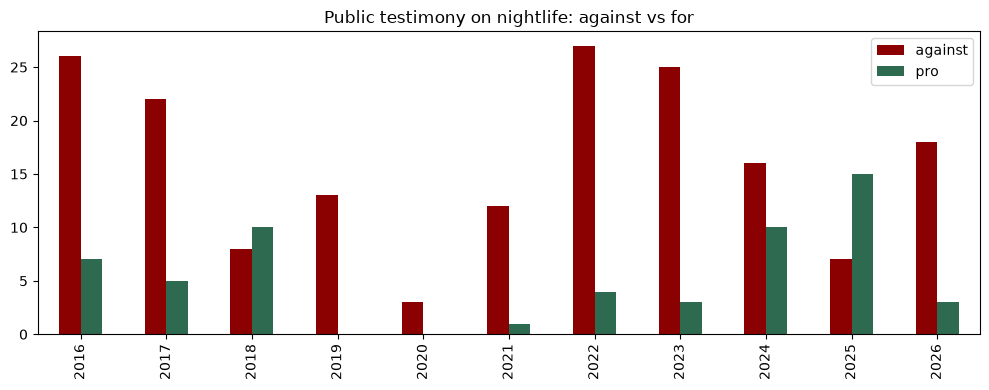

In [7]:
df = q("""
    SELECT year(m.date) AS yr,
           count(*) FILTER (WHERE s.position = 'against') AS against,
           count(*) FILTER (WHERE s.position = 'for') AS pro
    FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE s.topic ILIKE '%liquor%' OR s.topic ILIKE '%sla%'
       OR s.topic ILIKE '%bar%' OR s.topic ILIKE '%license%' OR s.topic ILIKE '%applicant%'
    GROUP BY 1 ORDER BY 1
""")
ax = df.set_index("yr")[["against", "pro"]].plot(
    kind="bar", figsize=(10, 4), color=["#8B0000", "#2d6a4f"])
ax.set_title("Public testimony on nightlife: against vs for")
ax.set_xlabel("")
plt.tight_layout()
df

## 5. The biography of an address

Some storefronts never leave the docket. 113 Franklin Street appears 16 times
in ten years — a decade of openings, renewals, and ownership churn at a single
address, told entirely through license paperwork.

In [8]:
q("""
    SELECT m.date, l.applicant_name, l.dba, l.application_type,
           coalesce(l.board_action, l.committee_recommendation) AS action
    FROM licenses l JOIN meetings m USING (meeting_id)
    WHERE l.address ILIKE '%113 Franklin%'
    ORDER BY m.date
""")

,date,applicant_name,dba,application_type,action
0,2016-06-14,Clouet,NaN,other,NaN
1,2017-10-17,Starlite Walker LLC,Ramona,renewal,NaN
2,2017-11-14,Starlite Walker LLC,Ramona,renewal,approval
3,2017-11-14,Starlite Walker LLC,Ramona,renewal,approval
4,2019-02-12,Clouet LLC,NaN,renewal,NaN
5,2019-09-10,Clouet LLC,Cassette,alteration,NaN
6,2019-10-10,Starlite Walker LLC,Ramona,alteration,NaN
7,2019-10-10,Starlite Walker LLC,Ramona,renewal,NaN
8,2019-10-10,Clouet LLC,Cassette,alteration,Approval
9,2019-10-10,Closet LLC,Cassette,renewal,NaN


## The receipts: what this cost

Every extraction call was cost-logged. The whole dataset — 108 meetings,
~5,000 license records, 1,200+ votes — came out of the PDFs for about the
price of two cocktails at any establishment on this docket.

In [9]:
q("""
    SELECT text_source,
           count(*) AS meetings,
           sum(pages_minutes_body) AS body_pages,
           sum(pages_attachments_dropped) AS pages_dropped,
           round(sum(cost_usd), 2) AS extraction_cost_usd
    FROM meetings GROUP BY 1 ORDER BY extraction_cost_usd DESC
""")

,text_source,meetings,body_pages,pages_dropped,extraction_cost_usd
0,native,43,2814.0,10856.0,4.66
1,embedded_ocr,33,1305.0,2392.0,2.73
2,vision_ocr,24,319.0,822.0,1.40
3,mixed,10,678.0,2912.0,1.04


## Caveats, honestly stated

- **Voice votes** ("unanimously carried", no numeric tally) are stored as
  `yes=0, no=0`; tally analyses filter them with `yes + no > 0`.
- A motion can **fail with a yes-majority**: board recommendations require a
  majority of *appointed* members, not of those voting.
- 2016–21 numbers ride on OCR (vision or embedded). A three-meeting golden
  set — one per document era — gates vote-tally accuracy at 100% exact match
  before any of the vote claims above ship.
- Extraction was done by `claude-haiku-4-5` on Amazon Bedrock; every record
  keeps a verbatim `source_snippet` for spot-checking against the PDFs.